In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# chargement du dataset nettoyé du Jalon 3
df = pd.read_csv("../data/processed/comptages_prepares.csv", sep=";" )
print(df.columns)

# Vérification de l'importation
print("Dimensions du DataFrame :", df.shape)
df.head()

Index(['iu_ac', 'libelle', 't_1h', 'q', 'k', 'etat_trafic', 'etat_barre'], dtype='str')
Dimensions du DataFrame : (148376, 7)


,iu_ac,libelle,t_1h,q,k,etat_trafic,etat_barre
0,5601,Bd_Grenelle,2026-09-01 01:00:00+02:00,76.0,0.80889,Fluide,Ouvert
1,5602,Bd_Grenelle,2026-09-01 01:00:00+02:00,199.0,1.85278,Fluide,Ouvert
2,5604,Bd_Grenelle,2026-09-01 01:00:00+02:00,76.0,1.22445,Fluide,Ouvert
3,5606,Bd_Grenelle,2026-09-01 01:00:00+02:00,199.0,1.95611,Fluide,Ouvert
4,5608,Bd_Grenelle,2026-09-01 01:00:00+02:00,199.0,6.04333,Fluide,Ouvert


In [7]:

# options d'affichage Pandas
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

# definition du style graphique
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "figure.autolayout": True})


# Préparation des variables temporelles
df["t_1h"] = pd.to_datetime(df["t_1h"], utc=True).dt.tz_convert("Europe/Paris")
df["heure"] = df["t_1h"].dt.hour
df["jour_semaine"] = df["t_1h"].dt.day_name()
df["est_weekend"] = df["t_1h"].dt.dayofweek >= 5
df["type_jour"] = df["est_weekend"].map({True: "Week-end", False: "Semaine"})

# Ordre des jours pour la heatmap
jours_ordre = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday",]

traduction_jours = ["Lundi","Mardi", "Mercredi","Jeudi","Vendredi","Samedi","Dimanche",]



VISUEL 1 : Comparaison Semaine vs Week-end par Axe

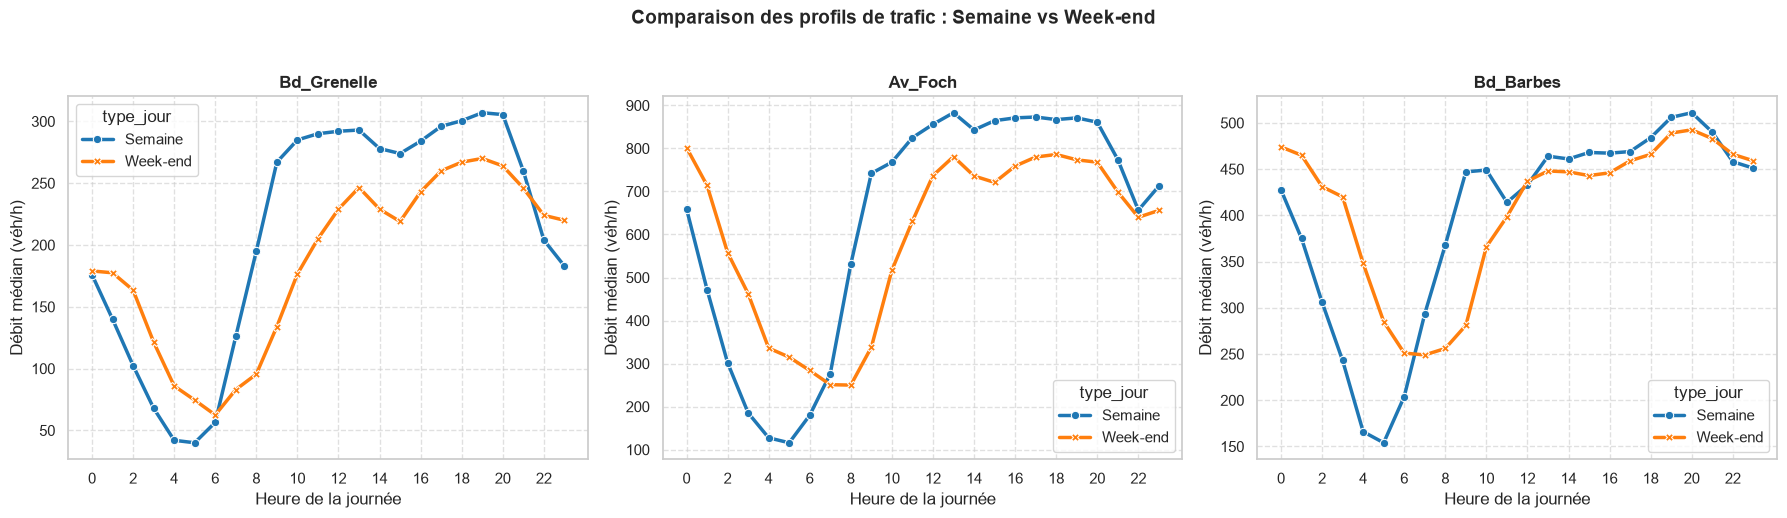

In [24]:
axes_unique = df["libelle"].unique()
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, nom_axe in zip(axes, axes_unique):
    data_axe = df[df["libelle"] == nom_axe]
    df_profile = (
        data_axe.groupby(["heure", "type_jour"])["q"].median().reset_index()
    )

    sns.lineplot(
        data=df_profile,
        x="heure",
        y="q",
        hue="type_jour",
        style="type_jour",
        markers=True,
        dashes=False,
        ax=ax,
        palette={"Semaine": "#1f77b4", "Week-end": "#ff7f0e"},
        linewidth=2.5,
    )

    ax.set_title(f"{nom_axe}", fontweight="bold")
    ax.set_xlabel("Heure de la journée")
    ax.set_ylabel("Débit médian (véh/h)")
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, linestyle="--", alpha=0.6)

plt.suptitle(
    "Comparaison des profils de trafic : Semaine vs Week-end",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)
plt.show()

Analyse : 
-Avenue Foch: L'axe est très emprunté aux heures de pointe en semaine de 8h à 20h car tout le monde vaque a ses activites. Le week-end, le trafic grimpe plus tard aux environs de midi mais reste en dessous de celui des jours de travail.  

-Boulevard Barbès: En semaine, le trafic s'intensifie progressivement à partir de 7h pour culminer en fin de journée vers 19h-20h. Le week-end, la circulation nocturne reste tout de meme élevée entre 0h et 4h du matin mais egalement entre 20h et 22h preuve que certainement les individus sortent pour se divertir en empruntant cette voie la.   

-Boulevard Grenelle: debit plus faible (< 300 véh/h). Tout comme les deux precedentes le trafic est plus important en semaine en comparaison au weekend, cependant cette voie est bien moins empruntee par rapport aux deuc autres.

VISUEL 2 : Heatmap globale du Taux d'Occupation de la voie (Jours x Heures)

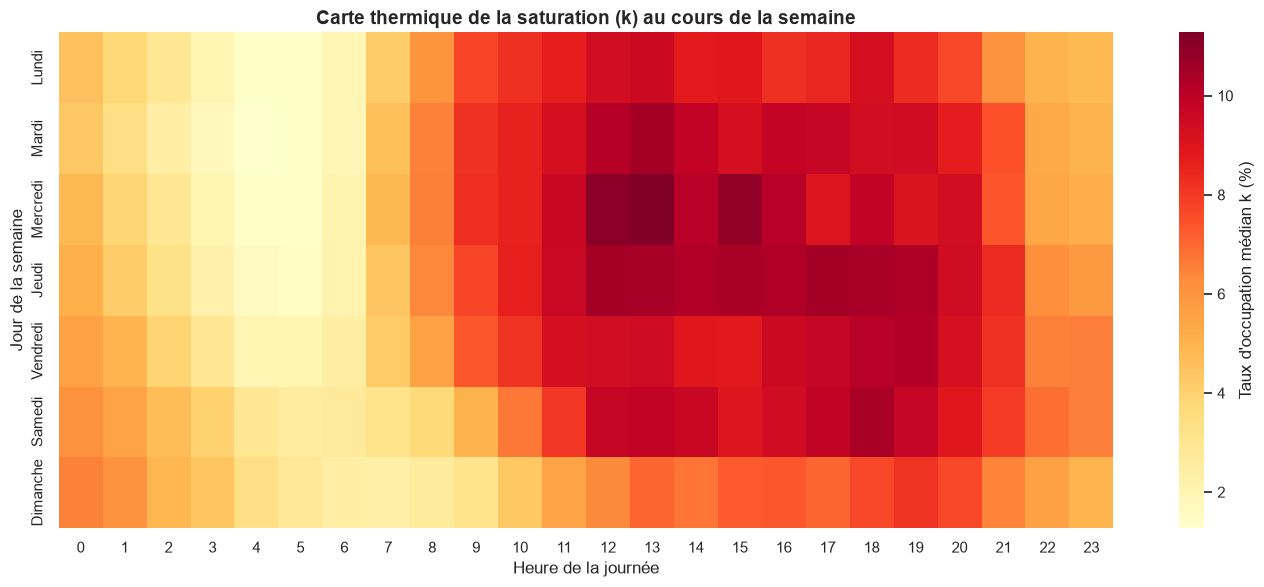

In [25]:
heatmap_data = df.pivot_table(
    index="jour_semaine", columns="heure", values="k", aggfunc="median"
).reindex(jours_ordre)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=False,
    fmt=".1f",
    cbar_kws={"label": "Taux d'occupation médian k (%)"},
    yticklabels=traduction_jours,
)

plt.title(
    "Carte thermique de la saturation (k) au cours de la semaine",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Heure de la journée")
plt.ylabel("Jour de la semaine")
plt.show()

La semaine (Lundi–Vendredi) : Zone rouge sombre marquée de 9h à 19h, ce que le taux d'occupation de la voie augmente de facon continue sur les heures de bureau. Le cœur de la semaine notamment Mercredi/Jeudi vers 11h-13h est encore plus marqué ce qui signifie que sur ces deux jours entre 11h et 13h la route est encore plus occupee en comparaison aux 3 autres jours.   

Le week-end (Samedi–Dimanche) : La saturation se décale nettement , on observe des matinées très claires (la voie n'est pas tres occupee, le traffic est fluide), puis une montée progressive en soirée avec un pic marqué le Samedi après-midi/soirée (16h-18h) ce qui correspond a la periode ou les personnes sortent pour se divertir en general. 

VISUEL 3 : Diagramme Fondamental (Débit q vs Taux d'occupation k)

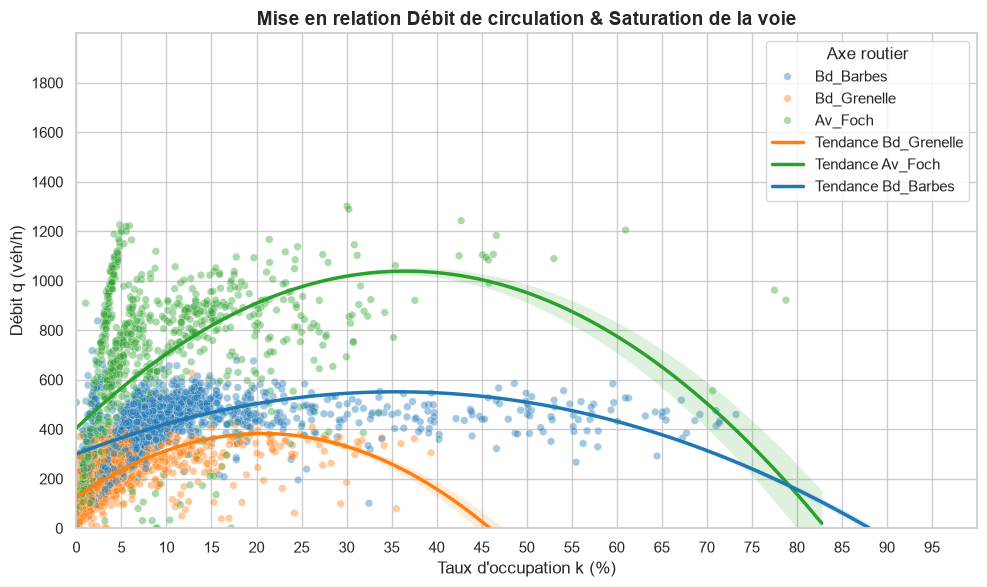

In [22]:
plt.figure(figsize=(10, 6))

couleurs_axes = {
    "Av_Foch": "#2ca02c",  # Vert
    "Bd_Barbes": "#1f77b4",  # Bleu
    "Bd_Grenelle": "#ff7f0e",  # Orange
}

# Plot des points réels échantillonnés + courbe de tendance
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="k",
    y="q",
    hue="libelle",
    palette=couleurs_axes,
    alpha=0.4,
    s=30,
)

# Courbe de régression polynomiale (ordre 2) pour illustrer la parabole
for nom_axe in axes_unique:
    sub = df[df["libelle"] == nom_axe].dropna(subset=["q", "k"])
    sns.regplot(
        data=sub,
        x="k",
        y="q",
        scatter=False,
        order=2,
        label=f"Tendance {nom_axe}",
        color=couleurs_axes[nom_axe],
        line_kws={"linewidth": 2.5},
    )

plt.xticks(np.arange(0, 100, 5))

plt.yticks(np.arange(0, 2000, 200))

plt.title(
    "Mise en relation Débit de circulation & Saturation de la voie",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Taux d'occupation k (%)")
plt.ylabel("Débit q (véh/h)")
plt.legend(title="Axe routier")
plt.xlim(0, 100)
plt.ylim(0, 2000)
plt.show()

La parabole decrit le comportement physique des vehicules pour chaque axe.

Avenue Foch : C’est l'axe qui écoule le plus grand volume de trafic.  Il atteint sa capacité optimale aux alentours de 30 à 35% d'occupation, où il s'écoule environ 1050 véhicules/heure. Lorsque la saturation dépasse 40%, le débit chute progressivement. Ceci est logique et traduit simplement que la circulation n'est plus tres fluide et donc moins de vehicules passent.

Boulevard Barbès :  C’est le seul axe qui présente une grande quantité de points étalés très loin sur la droite, entre 45% et 70% d'occupation.Cela montre que le Boulevard Barbès passe une part importante de son temps en état de saturation plus ou moins avancee, comme des bouchons qui stagnent. Même si des véhicules occupent presque toute la chaussée, le débit reste bloqué à un niveau moyen

Boulevard Grenelle : C'est la voie la moins chargée des trois.Les points s'arrêtent quasi tous avant 40% d'occupation. Il ne subit presque jamais de saturation extrême on peut conclure qu'il fonctionne majoritairement la circulation fluide, mais sa capacité physique totale est limitée.  